In [4]:
import pandas as pd

In [5]:
df=pd.read_csv('../data/processed/final_featuresWord2vec.csv')

In [6]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity,w2v_similarity
0,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,34,34,8,8,7,9,0.777778,0,88,88,0.745125,0.996471
1,368101,12736,104117,what are some of the best side dish for crab c...,what are some good side dish for buffalo chicken,0,53,51,11,9,6,14,0.428571,2,71,71,0.750571,0.927082
2,70497,121486,121487,which is more advis and better materi for a cr...,what is the best server setup for buddypress,0,96,45,16,8,2,22,0.090909,51,37,45,0.053934,0.713124
3,226567,254474,258192,how do i improv logic program skills,how can i improv my logic skill for programming,1,44,52,7,9,4,12,0.333333,8,67,69,0.470717,0.925362
4,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,38,29,9,7,3,12,0.250000,9,68,61,0.541497,0.860121


In [7]:
#define X and Y


X=df[
    [
        'q1_len',
        'q2_len',
        'q1_words',
        'q2_words',
        'common_words',
        'word_share',
        'len_diff',
        'fuzz_ratio',
        'partial_ratio',
        'tfidf_cosine_similarity',
        'w2v_similarity' 
    ]
]

y=df['is_duplicate']

# Logistic Regression

In [8]:
#train_test_split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
from sklearn.linear_model import LogisticRegression


model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)

In [35]:
results_df=pd.read_csv('model_results.csv')

In [36]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118
8,BiLSTM,Deep Learning Approach,0.7334
9,Siamese,Dl approach,0.7279


In [52]:
results_df = results_df.iloc[6:].reset_index(drop=True)


In [53]:
results_df

,model,features,accuracy
0,SimpleRnn,Deep Learning Approach,0.7202
1,LSTM,Deep Learning Approach,0.7118
2,BiLSTM,Deep Learning Approach,0.7334
3,Siamese,Dl approach,0.7279


In [54]:
new_row=pd.DataFrame([
    {
        "model":"Logistic Regression",
        "features":"TF-IDF+Word2vec",
        "accuracy":acc
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [41]:
#checking accuracy

from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

print("Accuracy",accuracy_score(y_test,y_pred))
acc=accuracy_score(y_test,y_pred)

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy 0.6711

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      6309
           1       0.56      0.52      0.54      3691

    accuracy                           0.67     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.67      0.67      0.67     10000



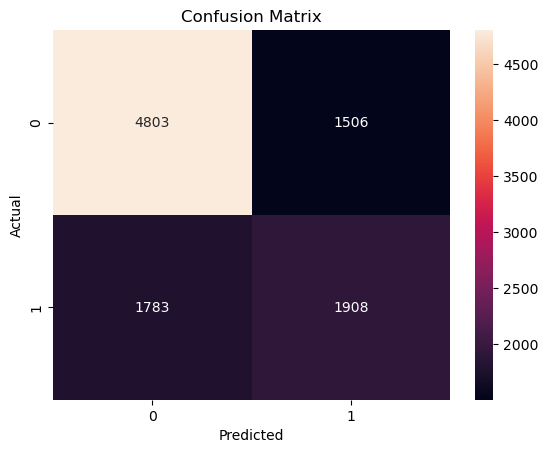

In [18]:
import matplotlib.pyplot as plt
import  seaborn as sns

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

print("Random Forest Accuracy : ", accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy :  0.7289


In [55]:
new_row=pd.DataFrame([
    {
        "model":"Random Forest",
        "features":"TF-IDF+Word2vec",
        "accuracy":accuracy_score(y_test,y_pred_rf)
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [44]:
#feature importance

import numpy as np

importances = rf.feature_importances_

for i, col in enumerate(X.columns):
    print(col, ":", importances[i])

q1_len : 0.07890063789831958
q2_len : 0.07842225041992351
q1_words : 0.044884422557124506
q2_words : 0.04602076994591748
common_words : 0.04366812768925822
word_share : 0.12670609425000431
len_diff : 0.07182125079004376
fuzz_ratio : 0.13713362902259968
partial_ratio : 0.10422471566029001
tfidf_cosine_similarity : 0.1392092271405062
w2v_similarity : 0.12900887462601274


In [20]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.3/69.5 MB 16.6 MB/s eta 0:00:05
   --- ------------------------------------ 6.8/69.5 MB 26.2 MB/s eta 0:00:03
   ---- ----------------------------------- 7.9/69.5 MB 18.3 MB/s eta 0:00:04
   ----- ---------------------------------- 8.9/69.5 MB 13.3 MB/s eta 0:00:05
   ----- ---------------------------------- 10.0/69.5 MB 12.8 MB/s eta 0:00:05
   ------ --------------------------------- 12.1/69.5 MB 10.9 MB/s eta 0:00:06
   ------- -------------------------------- 13.1/69.5 MB 10.1 MB/s eta 0:00:06
   -------- ------------------------------- 14.4/69.5 MB 9.5 MB/s eta 0:00:06
   --------- ------------------------------ 15.7/69.5 MB 9.1 MB/s eta 0:00:06
   --------- ------------------------------ 16.8/69.5 MB 8.8 MB/s eta 0:00:06
   ---------- ----------------------------- 18.6/69.5 MB 8.5 MB/s eta

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [25]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [29]:
y_pred_xgb=xgb_model.predict(X_test)

print("XGBoost Accuracy: ",accuracy_score(y_test,y_pred_xgb))

print("\nClassification Report : \n")
print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy:  0.7442

Classification Report : 

              precision    recall  f1-score   support

           0       0.82      0.76      0.79      6309
           1       0.64      0.71      0.67      3691

    accuracy                           0.74     10000
   macro avg       0.73      0.74      0.73     10000
weighted avg       0.75      0.74      0.75     10000



In [56]:
new_row=pd.DataFrame([
    {
        "model":"XGB_BOOST",
        "features":"TF-IDF+Word2vec",
        "accuracy":accuracy_score(y_test,y_pred_xgb)
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [116]:
results_df=pd.DataFrame(results)

In [57]:
results_df

,model,features,accuracy
0,SimpleRnn,Deep Learning Approach,0.7202
1,LSTM,Deep Learning Approach,0.7118
2,BiLSTM,Deep Learning Approach,0.7334
3,Siamese,Dl approach,0.7279
4,Logistic Regression,TF-IDF+Word2vec,0.6711
5,Random Forest,TF-IDF+Word2vec,0.7289
6,XGB_BOOST,TF-IDF+Word2vec,0.7442


In [58]:
results_df.to_csv("model_results.csv", index=False)

In [ ]:
# accuracy has improved with word 2 vec

# here i have come after completing 4 th notebook with deep learning approches

# Model Saving

In [59]:
import pandas as pd

results_df = pd.read_csv('model_results.csv')

In [60]:
results_df

,model,features,accuracy
0,SimpleRnn,Deep Learning Approach,0.7202
1,LSTM,Deep Learning Approach,0.7118
2,BiLSTM,Deep Learning Approach,0.7334
3,Siamese,Dl approach,0.7279
4,Logistic Regression,TF-IDF+Word2vec,0.6711
5,Random Forest,TF-IDF+Word2vec,0.7289
6,XGB_BOOST,TF-IDF+Word2vec,0.7442


we can see that XGBoost has highest accuracy so we will use it

In [61]:
from xgboost import XGBClassifier
#training on whole dataset
final_xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [62]:
#save model

import pickle

with open('../models/xgb_model.pkl','wb') as f:
    pickle.dump(final_xgb,f)

print("model saved")

model saved
